<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula02c_equa%C3%A7%C3%A3o_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

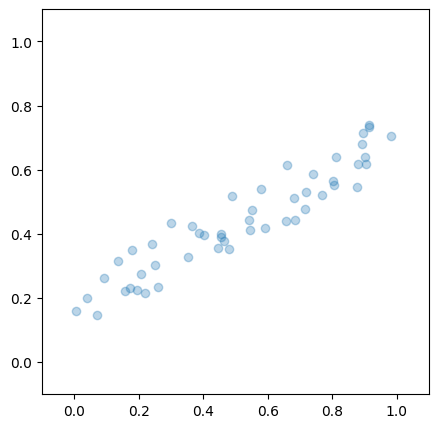

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=50, slope=0.5, intercept=0.2):
  X = np.random.uniform(size=(n,1))
  Noise = (np.random.rand(n, 1)-0.5)*0.2
  y = slope*X + intercept + Noise
  return X, y.flatten()

def plotDataset(X, y):
  plt.plot(X[:,0], y, 'o', alpha=0.3)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

X, y = createDataset()
plt.figure(figsize=(5,5))
plotDataset(X, y)
plt.show()

MSE: 0.0029871172914063574
Weights: [0.16750335 0.52893676]


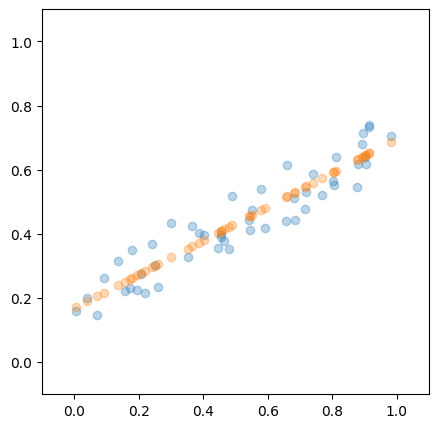

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import mean_squared_error

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class LinearRegression(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    # equação normal
    X = include_bias(X)
    self.w_ = np.linalg.pinv(X) @ y
    return self

  def predict(self, X):
    X = include_bias(X)
    ypred = self.w_ @ X.T
    return ypred

clf = LinearRegression()
clf.fit(X, y)
ypred = clf.predict(X)
print(f"MSE: {mean_squared_error(y, ypred)}")
print(f"Weights: {clf.w_}")
plt.figure(figsize=(5,5))
plotDataset(X, y)
plotDataset(X, ypred)
plt.show()